In [43]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# load dataset - Dataset is a csv file from Kaggle that contains Netflix movie 
# and TV show data points
df = pd.read_csv("netflix_titles.csv")

In [45]:
# Data summary
print("Dataset Shape:", df.shape)

Dataset Shape: (8807, 12)


In [46]:
print("Column info:")
df.info()

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [48]:
print("First 5 Rows:")
df.head()

First 5 Rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [49]:
print("Descriptive Statistics:")
df.describe(include="all")

Descriptive Statistics:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [ ]:
# Research Questions:
# Question 1: How does the distribution of content type, movies vs TV shows,
# vary between genres?
# Question 2: What is the rating distribution for the Netflix titles?

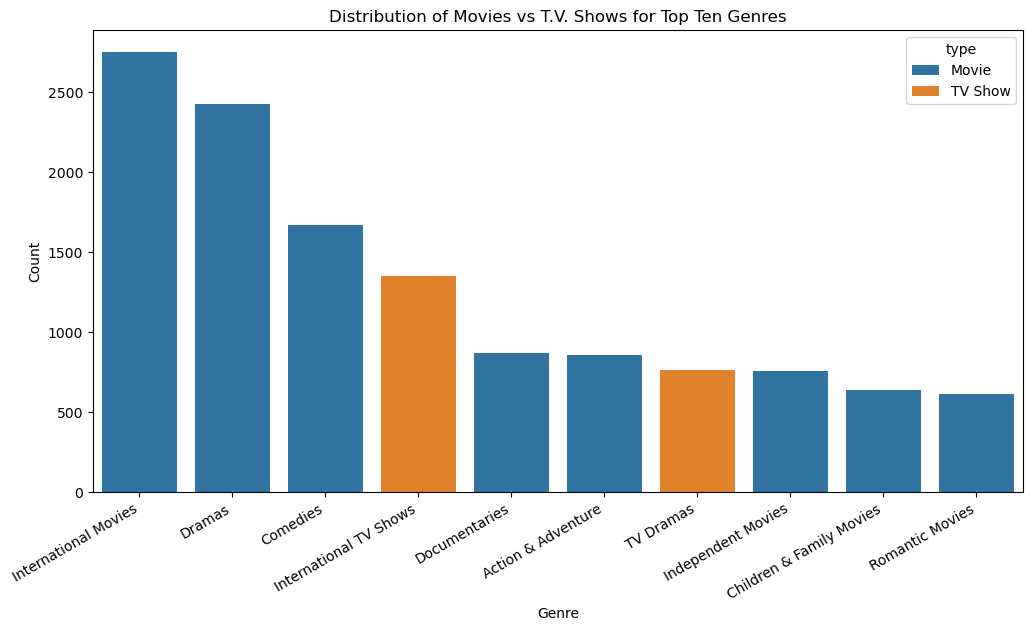

In [50]:
# Question 1 - Visualization
# Clean genre column - using strip to get rid of whitespace
df_genres['listed_in'] = df_genres['listed_in'].str.strip()

# Get top ten genres by count then filter the data to give the list of items
# in the top 10 for visualization
top10_genres = df_genres['listed_in'].value_counts().nlargest(10).index
df_top10 = df_genres[df_genres['listed_in'].isin(top10_genres)]

# Plot the diagram
plt.figure(figsize=(12,6))
sns.countplot(x="listed_in", hue="type", data=df_top10, order=top10_genres)
plt.title("Distribution of Movies vs TV Shows for Top Ten Genres")
plt.ylabel("Count")
plt.xlabel("Genre")
plt.xticks(rotation=30, ha="right")
plt.show()

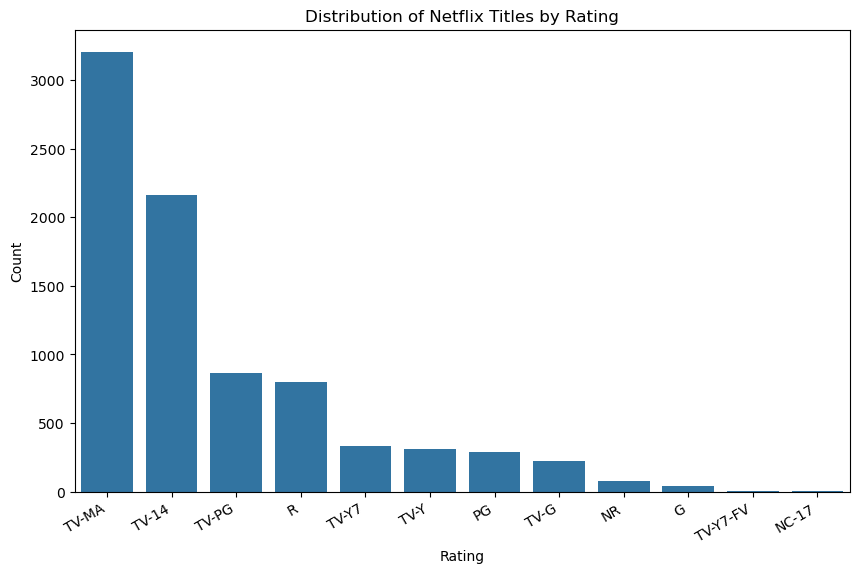

In [51]:
# Question 2 - Visualization
# Clean rating column - non-rating values are included in the rating column
# create rating list
ratings_list = [
    "TV-MA", "TV-14", "TV-PG", "TV-Y", "TV-Y7", "TV-Y7-FV", "TV-G",
    "PG", "R", "G", "NC-17", "NR"
]
# filter list to exclude ratings not in the ratings list
df_ratings = df[df["rating"].isin(ratings_list)].copy()

# plot diagram
plt.figure(figsize=(10,6))
sns.countplot(x="rating", data=df_ratings, order=df_ratings['rating'].value_counts().index)
plt.xticks(rotation=30, ha="right")
plt.title("Distribution of Netflix Titles by Rating")
plt.ylabel("Count")
plt.xlabel("Rating")
plt.show()

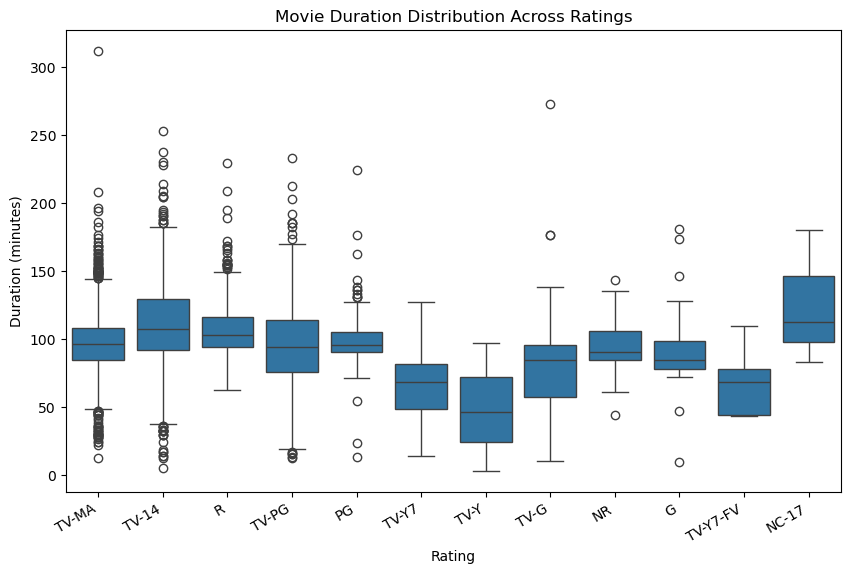

In [35]:
# Additional visualizations to better understand the data and my questions
# Boxplot of movies durations by rating
df_movies = df_ratings[df_ratings["type"]=="Movie"].copy()
df_movies["duration"] = df_movies["duration"].str.replace(" min","").astype(float)

plt.figure(figsize=(10,6))
sns.boxplot(x="rating", y="duration", data=df_movies,
            order=df_movies['rating'].value_counts().index)
plt.xticks(rotation=30, ha="right")
plt.title("Movie Duration Distribution by Ratings")
plt.ylabel("Duration (minutes)")
plt.xlabel("Rating")
plt.show()

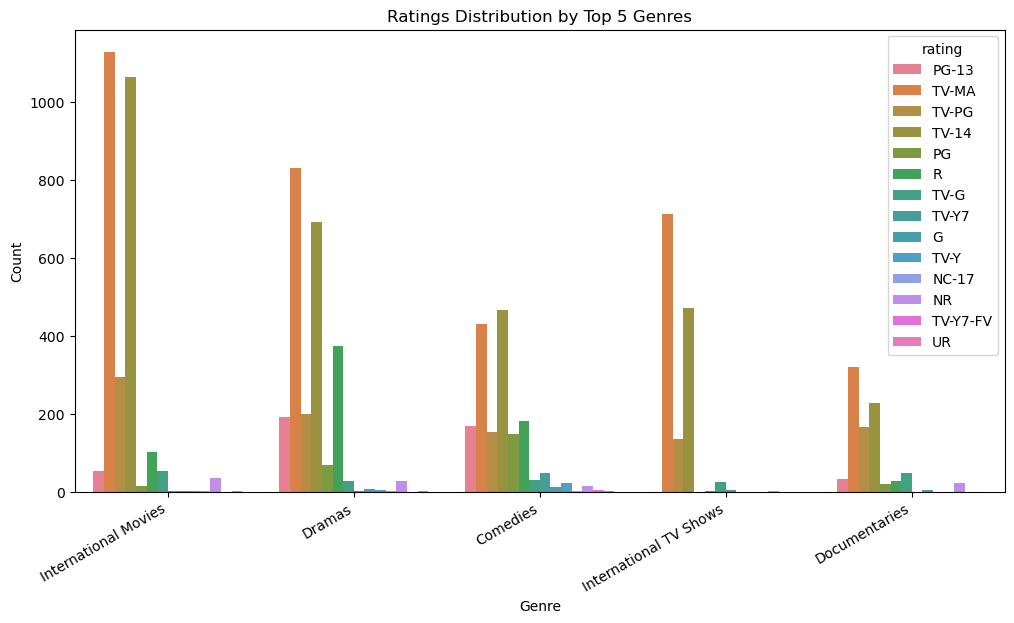

In [52]:
# Bivariate plot to that shows how genres, ratings and type are related
# Only using the top 5 genres to keep the visualization understandable
top5_genres = df_genres['listed_in'].value_counts().nlargest(5).index
df_top5 = df_genres[df_genres['listed_in'].isin(top5_genres)]

# plot diagram
plt.figure(figsize=(12,6))
sns.countplot(x="listed_in", hue="rating", data=df_top5, order=top5_genres)
plt.xticks(rotation=30, ha="right")
plt.title("Ratings Distribution by Top 5 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()